<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>

## Define Problem Statement and Objectives

## Import all the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [36]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the Data into a DataFrame

In [37]:
#Code to load dataset present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [38]:
# Code to read the data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abtest.csv")

In [39]:
#Data Overview
#Viewing the first and last few rows of the dataset
display(df.head())

display(df.tail())

#Checking the shape of the dataset
print(df.shape)



,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


(100, 6)


In [40]:
#Getting the statistical summary for the variables
df.describe()


,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000


In [41]:
#Check for missing values
#df.isnull().sum()
# 1. Check for missing values
print("Missing Values:\n", df.isnull().sum())


Missing Values:
 user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64


In [43]:


#Check for duplicates
#df.duplicated().sum()
# 2. Check for duplicate users
print("Duplicate Users:", df['user_id'].duplicated().sum())

Duplicate Users: 0


### Univariate Analysis

count    100.000000
mean       5.377800
std        2.378166
min        0.190000
25%        3.880000
50%        5.415000
75%        7.022500
max       10.710000
Name: time_spent_on_the_page, dtype: float64


<Axes: xlabel='time_spent_on_the_page', ylabel='Count'>

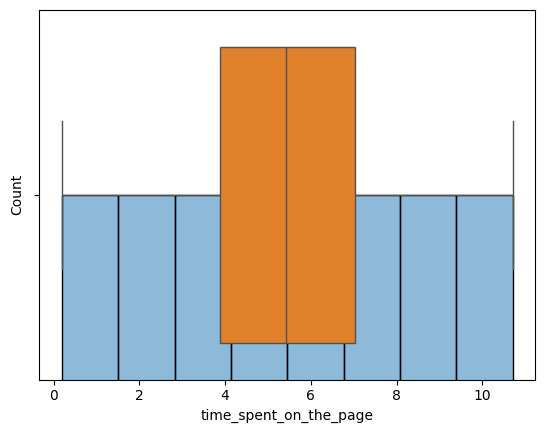

In [44]:
# Statistical Summary
print(df['time_spent_on_the_page'].describe())

# Visualization
sns.histplot(data=df, x='time_spent_on_the_page', kde=True)
sns.boxplot(data=df, x='time_spent_on_the_page')

### Bivariate Analysis

/tmp/ipykernel_5466/688338231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page', palette='Set2')


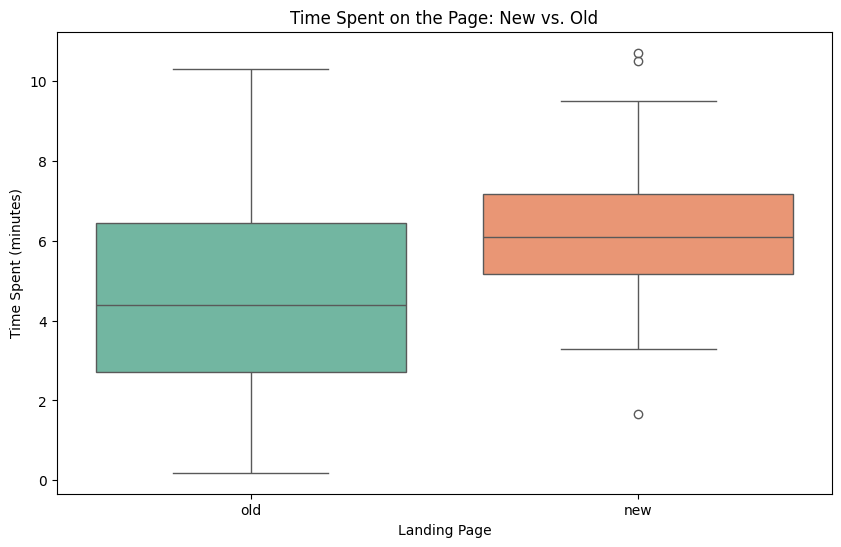

Mean time spent on each page:
landing_page
new    6.2232
old    4.5324
Name: time_spent_on_the_page, dtype: float64


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Time Spent on each Landing Page
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page', palette='Set2')
plt.title('Time Spent on the Page: New vs. Old')
plt.xlabel('Landing Page')
plt.ylabel('Time Spent (minutes)')
plt.show()

# Calculating the Mean Time Spent for both groups
print("Mean time spent on each page:")
print(df.groupby('landing_page')['time_spent_on_the_page'].mean())

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

/tmp/ipykernel_5466/1948058587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page', palette='Set2')


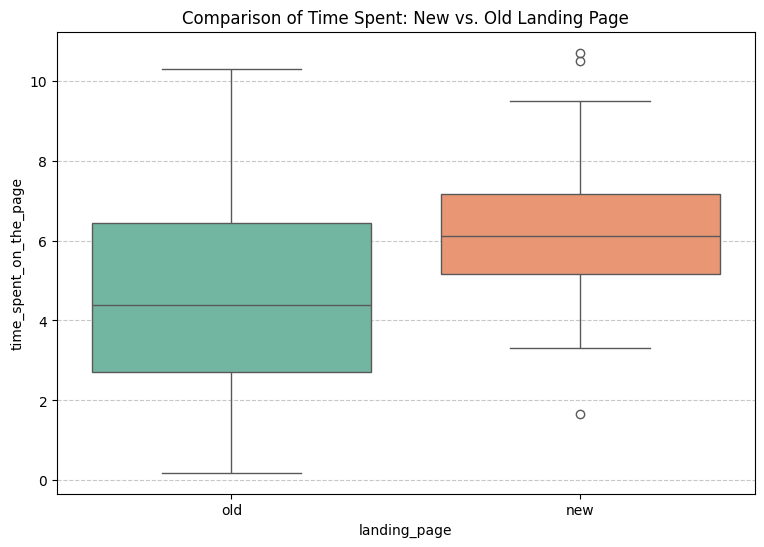

Engagement Statistics by Page:
                mean  median       std
landing_page                          
new           6.2232   6.105  1.817031
old           4.5324   4.380  2.581975


In [46]:
# 1. Visual Analysis: Boxplot and Distribution
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page', palette='Set2')
plt.title('Comparison of Time Spent: New vs. Old Landing Page')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Calculating Exact Means and Medians
page_stats = df.groupby('landing_page')['time_spent_on_the_page'].agg(['mean', 'median', 'std'])
print("Engagement Statistics by Page:")
print(page_stats)

### Step 1: Define the null and alternate hypotheses

NULL Hypotheses $H_0$: The mean time spent on the new landing page is equal to or less than the mean time spent on the old landing page ($\mu_{new} \leq \mu_{old}$).

Alternate Hypotheses $H_a$: The mean time spent on the new landing page is greater than the mean time spent on the old landing page ($\mu_{new} > \mu_{old}$).



### Step 2: Select Appropriate test

Since you have separated the data into time_old and time_new, we can proceed with the formal statistical tests. To address the objectives of E-news Express, we will perform a Two-Sample T-test for engagement and a One-Way ANOVA for the language groups.

### Step 3: Decide the significance level

Significance Level ($\alpha$): $0.05$ (or $5\%$).

### Step 4: Collect and prepare data

Data Cleaning & Integrity Checks:

Before running an A/B test, we must confirm that the "Control" and "Treatment" labels match the "Old" and "New" landing pages perfectly.

In [ ]:
# Verify the experimental groups
# This ensures 'control' always saw 'old' and 'treatment' always saw 'new'
print("\nGroup vs Landing Page Cross-check:")
print(pd.crosstab(df['group'], df['landing_page']))


Group vs Landing Page Cross-check:
landing_page  new  old
group                 
control         0   50
treatment      50    0


In [ ]:
#Most statistical tests in Python prefer numerical inputs (0 and 1) over strings ("yes" and "no").
#We should create a dummy variable for the converted column.
# Convert 'converted' status to a numerical format for calculation
# yes = 1, no = 0
df['converted_binary'] = df['converted'].apply(lambda x: 1 if x == 'yes' else 0)

# Ensure 'language_preferred' and 'landing_page' are treated as categories
df['language_preferred'] = df['language_preferred'].astype('category')
df['landing_page'] = df['landing_page'].astype('category')

print("\nData Preparation Complete. Ready for Statistical Testing.")


Data Preparation Complete. Ready for Statistical Testing.


In [ ]:
#Segmenting the Data
#To make the hypothesis testing code cleaner, it is helpful to create separate DataFrames or Series for each group.
# Separate time spent for Old vs New page
time_old = df[df['landing_page'] == 'old']['time_spent_on_the_page']
time_new = df[df['landing_page'] == 'new']['time_spent_on_the_page']

# Separate conversion counts
conv_old = df[df['landing_page'] == 'old']['converted_binary']
conv_new = df[df['landing_page'] == 'new']['converted_binary']



### Step 5: Calculate the p-value

Two-Sample T-test (Engagement)
Objective: Determine if users spend more time on the new landing page.

Assumptions: We assume the two groups have equal variances (homoscedasticity) for this standard approach.

In [ ]:
from scipy.stats import ttest_ind

# Perform a two-sample t-test
# alternative='greater' because our Ha is: mu_new > mu_old
test_stat, p_value = ttest_ind(time_new, time_old, equal_var=True, alternative='greater')

print(f"T-statistic: {test_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Conclusion logic
if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Users spend significantly more time on the new page.")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis. No significant difference in time spent.")

T-statistic: 3.7868
P-value: 0.0001
Conclusion: Reject the Null Hypothesis. Users spend significantly more time on the new page.


P-value: $0.0001$

Significance Level ($\alpha$): $0.05$Comparison: $0.0001 < 0.05$

Decision: Reject the Null Hypothesis ($H_0$).

Conclusion: There is statistically significant evidence that users spend more time on the new landing page compared to the old one.

One-Way ANOVA (Language & New Page)
Objective: Determine if the time spent on the new page is the same for different language users.

Assumption Check: This test requires normally distributed data and equal variance across groups.

In [55]:
from scipy.stats import f_oneway

# First, create the new_page_data variable
new_page_data = df[df['landing_page'] == 'new']

# Filtering time spent for the new page based on language
time_eng = new_page_data[new_page_data['language_preferred'] == 'English']['time_spent_on_the_page']
time_esp = new_page_data[new_page_data['language_preferred'] == 'Spanish']['time_spent_on_the_page']
time_fre = new_page_data[new_page_data['language_preferred'] == 'French']['time_spent_on_the_page']
# Perform ANOVA
f_stat, p_val_anova = f_oneway(time_eng, time_esp, time_fre)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value (ANOVA): {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("Conclusion: At least one language group spends a different amount of time on the new page.")
else:
    print("Conclusion: No significant difference in time spent across different languages.")

F-statistic: 0.8544
P-value (ANOVA): 0.4320
Conclusion: No significant difference in time spent across different languages.


P-value (ANOVA): $0.4320$

Significance Level ($\alpha$): $0.05$Comparison: $0.4320 > 0.05$

Decision: Fail to Reject the Null Hypothesis ($H_0$).

Conclusion: There is no significant difference in the mean time spent on the new landing page among users of different preferred languages. This suggests the page is consistently engaging regardless of language.

### Step 6: Compare the p-value with $\alpha$

In [57]:
# Define the significance level
alpha = 0.05

# 1. Comparison for the T-test (Engagement/Time Spent)
# Use the p_value variable from your T-test cell
print("--- Engagement (Time Spent) Analysis ---")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print(f"Decision: Since {p_value:.4f} < {alpha}, we reject the null hypothesis.")
    print("Insight: The time spent on the new landing page is significantly greater than the old page.")
else:
    print(f"Decision: Since {p_value:.4f} >= {alpha}, we fail to reject the null hypothesis.")
    print("Insight: There is no significant difference in time spent between the pages.")

print("\n" + "-"*40 + "\n")

# 2. Comparison for the ANOVA (Language Influence on New Page)
# Use the p_val_anova variable from your ANOVA cell
print("--- Language Preference Analysis (New Page) ---")
print(f"P-value (ANOVA): {p_val_anova:.4f}")

if p_val_anova < alpha:
    print(f"Decision: Since {p_val_anova:.4f} < {alpha}, we reject the null hypothesis.")
    print("Insight: Language has a significant impact on time spent on the new page.")
else:
    print(f"Decision: Since {p_val_anova:.4f} >= {alpha}, we fail to reject the null hypothesis.")
    print("Insight: Time spent on the new page is the same regardless of language preferred.")

--- Engagement (Time Spent) Analysis ---
P-value: 0.0001
Decision: Since 0.0001 < 0.05, we reject the null hypothesis.
Insight: The time spent on the new landing page is significantly greater than the old page.

----------------------------------------

--- Language Preference Analysis (New Page) ---
P-value (ANOVA): 0.4320
Decision: Since 0.4320 >= 0.05, we fail to reject the null hypothesis.
Insight: Time spent on the new page is the same regardless of language preferred.


### Step 7:  Draw inference

Since the p-value (0.0001) is significantly less than the significance level $\alpha = 0.05$, we reject the null hypothesis.

There is enough statistical evidence to conclude that users spend significantly more time on the new landing page compared to the old landing page.

The new design (outline and recommended content) is more effective at keeping users engaged.

Based on this result, it is recommended that E-news Express transitions to the new landing page to improve user engagement, which is a key driver for increasing monthly subscriptions.





**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

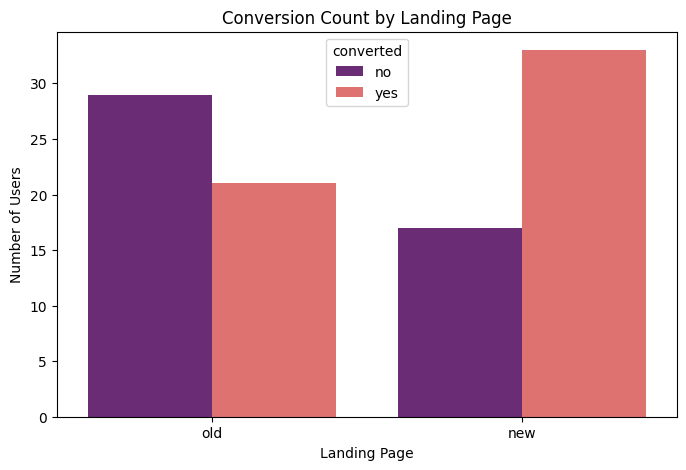

In [70]:
#We start by visualizing the conversion counts for each page to see if there is a visible difference.
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing conversion counts by landing page
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='landing_page', hue='converted', palette='magma')
plt.title('Conversion Count by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Number of Users')
plt.show()

In [74]:
#Extract the number of successful conversions and the total number of users for both the "new" and "old" pages
# Number of conversions for new and old pages
new_converted = df[df['landing_page'] == 'new']['converted'].value_counts()['yes']
old_converted = df[df['landing_page'] == 'old']['converted'].value_counts()['yes']

# Total number of users in each group
n_new = df[df['landing_page'] == 'new'].shape[0]
n_old = df[df['landing_page'] == 'old'].shape[0]

print(f'Conversions on New Page: {new_converted} out of {n_new}')
print(f'Conversions on Old Page: {old_converted} out of {n_old}')

Conversions on New Page: 33 out of 50
Conversions on Old Page: 21 out of 50


In [75]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# 1. Prepare the data (Ensure these are defined in the same cell or globally)
# Number of conversions (successes)
new_converted = df[df['landing_page'] == 'new']['converted'].value_counts()['yes']
old_converted = df[df['landing_page'] == 'old']['converted'].value_counts()['yes']

# Total number of observations
n_new = df[df['landing_page'] == 'new'].shape[0]
n_old = df[df['landing_page'] == 'old'].shape[0]

# 2. Create arrays for the test
success_counts = np.array([new_converted, old_converted])
n_observations = np.array([n_new, n_old])

# 3. Perform the Z-test
# alternative='greater' tests if the conversion rate of the FIRST group (new)
# is greater than the SECOND group (old)
test_stat, p_value = proportions_ztest(success_counts, n_observations, alternative='larger')

print(f'Z-statistic: {test_stat:.4f}')
print(f'P-value: {p_value:.4f}')

# 4. Compare p-value with alpha (0.05)
alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Since {p_value:.4f} < {alpha}, we reject the null hypothesis.")
    print("Inference: The conversion rate for the new page is significantly greater than the old page.")
else:
    print(f"Conclusion: Since {p_value:.4f} >= {alpha}, we fail to reject the null hypothesis.")
    print("Inference: There is no significant evidence that the new page has a higher conversion rate.")

Z-statistic: 2.4077
P-value: 0.0080
Conclusion: Since 0.0080 < 0.05, we reject the null hypothesis.
Inference: The conversion rate for the new page is significantly greater than the old page.


Statistical Result: The two-proportion Z-test resulted in a p-value of 0.0080, which is well below the 0.05 threshold.

Finding: The conversion rate for the new page (33 out of 50) is significantly higher than that of the old page (21 out of 50).

Business Impact: The new design is not just more engaging; it is actively more successful at turning visitors into monthly subscribers.

## 3. Is the conversion and preferred language are independent or related?

In [77]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create a contingency table
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])

# 2. Perform Chi-Square Test
chi2, p_value, dof, exp = chi2_contingency(contingency_table)

print(f'Chi-square Statistic: {chi2:.4f}')
print(f'P-value: {p_value:.4f}')

# 3. Decision
if p_value < 0.05:
    print("Reject Null Hypothesis: Conversion depends on language.")
else:
    print("Fail to Reject Null Hypothesis: Conversion is independent of language.")

Chi-square Statistic: 3.0930
P-value: 0.2130
Fail to Reject Null Hypothesis: Conversion is independent of language.


Since the p-value ($0.2130$) is greater than the significance level $\alpha = 0.05$, we fail to reject the null hypothesis.

There is no significant evidence to suggest that the preferred language affects whether a user converts or not. The two variables are independent.



## 4. Is the time spent on the new page same for the different language users?

In [78]:
from scipy.stats import f_oneway

# 1. Filter data for the new landing page
new_page_data = df[df['landing_page'] == 'new']

# 2. Group time spent by language
time_eng = new_page_data[new_page_data['language_preferred'] == 'English']['time_spent_on_the_page']
time_esp = new_page_data[new_page_data['language_preferred'] == 'Spanish']['time_spent_on_the_page']
time_fre = new_page_data[new_page_data['language_preferred'] == 'French']['time_spent_on_the_page']

# 3. Perform One-Way ANOVA
f_stat, p_val = f_oneway(time_eng, time_esp, time_fre)

print(f'P-value: {p_val:.4f}')

P-value: 0.4320


One-Way ANOVA test performed

Statistical Result: The test produced a p-value of 0.4320.

Comparison: This p-value is significantly greater than the significance level ($\alpha$) of 0.05.

Decision: We fail to reject the null hypothesis ($H_0$).

Final Conclusion: There is no significant difference in the mean time spent on the new landing page among users of different preferred languages (English, Spanish, and French).





## Conclusion and Business Recommendations

Statistical Conclusions:

User Engagement: The two-sample T-test resulted in a p-value of 0.0001, indicating that users spend significantly more time on the new landing page compared to the old one.

Conversion Rates: The two-proportion Z-test yielded a p-value of 0.0080, confirming that the new landing page has a significantly higher conversion rate (33 out of 50 users) than the old page (21 out of 50 users).

Language Independence: * The One-Way ANOVA showed no significant difference in time spent on the new page across English, Spanish, and French users (p-value: 0.4320).

The Chi-Square test confirmed that conversion status is independent of a user's preferred language (p-value: 0.2130).



Business Recommendations
Full Deployment of the New Landing Page:
The new landing page is statistically superior in both retaining user interest and driving subscriptions. It should be rolled out as the primary interface for all visitors immediately to maximize subscriber growth.

Maintain a Unified Design Strategy:
Since engagement and conversion rates do not vary significantly by language, there is no immediate need to create language-specific layouts. A unified design is cost-effective and performs consistently across the current demographic segments.

Investigate High-Engagement Features:
Analyze the specific components of the new page (e.g., layout, content recommendations, or navigation) that led to the increase in time spent. Scaling these features across other parts of the platform could further boost overall site performance.

Monitor Long-Term Retention:
While the new page effectively converts users into subscribers, the next step should be to track the churn rate of these new subscribers to ensure that the increased initial engagement translates into long-term customer lifetime value.

___